Lets Start by importing libraries  

In [16]:
import pandas as pd 
import seaborn as sns #we are not using now
import matplotlib.pyplot as plt
import numpy as np


Load the Data and check for any problem in data missing values etc.

In [17]:
df=pd.read_csv('data_tempvsice.csv')


In [18]:
print(df.head())
print(df.info())


   temperature_c  ice_cream_sales
0          32.57           285.34
1          24.27           214.91
2          27.61           246.19
3           9.18            89.77
4           7.62            77.50
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature_c    100 non-null    float64
 1   ice_cream_sales  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB
None


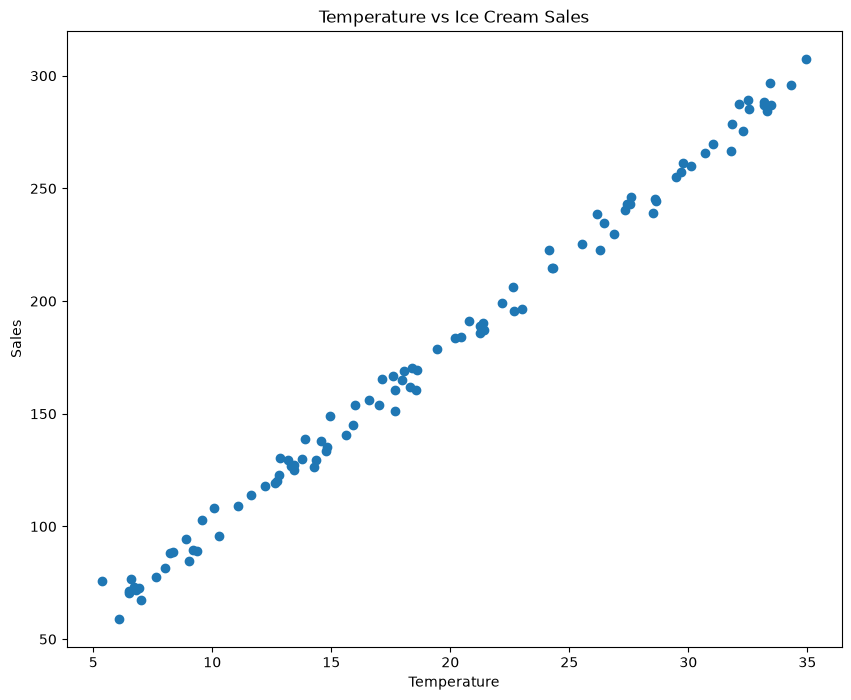

In [19]:
plt.figure(figsize=(10, 8))
plt.scatter(df.temperature_c, df.ice_cream_sales)
plt.title("Temperature vs Ice Cream Sales")
plt.xlabel("Temperature")
plt.ylabel("Sales")
plt.show()



In [20]:

# Converting to NumPy arrays to do easy 
X = df['temperature_c'].values.astype(float)
Y = df['ice_cream_sales'].values.astype(float)

# Compute means using np.mean()
meanX = np.mean(X)
meanY = np.mean(Y)

# print(f"Mean of X: {meanX}")
# print(f"Mean of Y: {meanY}")

# Instant calculations without 3 'for' loops)
# for X-Xbar,Y-Ybar and product of both
Xm = X - meanX
Ym = Y - meanY
XmY = Xm * Ym

# Calculate the slope using sum of Products and X-Xbar raise to power 2
m = np.sum(XmY) / np.sum(Xm**2)

print(f"Beta 1 or Slope is : {m:.4f}")
b=meanY-meanX*m
print(f"Beta 0 or Bias is :{b:.4f}")


Beta 1 or Slope is : 8.0883
Beta 0 or Bias is :18.6038


user inputs for plotting and storing those values in new list and calculating values of Y cap for that list with m and b we calculated earlier.

In [21]:
new_X_inputs = []
new_Y_predictions = []

print("Enter new temperature values to predict ice cream sales.")
print("Type 'Q' or 'Quit' at any time to finish and plot results.\n")

while True:
    user_input = input("Enter new X (temperature_c): ").strip()
    
    if user_input.upper() in ['Q', 'QUIT']:
        print("\nInputs saved.!")
        break
        
    try:
        x_val = float(user_input)
        y_pred = (m * x_val) + b
        
        new_X_inputs.append(x_val)
        new_Y_predictions.append(y_pred)
        
        print(f"For Value of X (Temperature): {x_val}-> Predicted Y (Sales): {y_pred:.2f}\n")
        
    except ValueError:
        print("Invalid input! Please enter a valid number or 'Q' to quit.\n")


Enter new temperature values to predict ice cream sales.
Type 'Q' or 'Quit' at any time to finish and plot results.



For Value of X (Temperature): 40.0-> Predicted Y (Sales): 342.14


Inputs saved.!


After we have our X and Predicted Y, We can go for Plotting on Scatter Plot with plt 

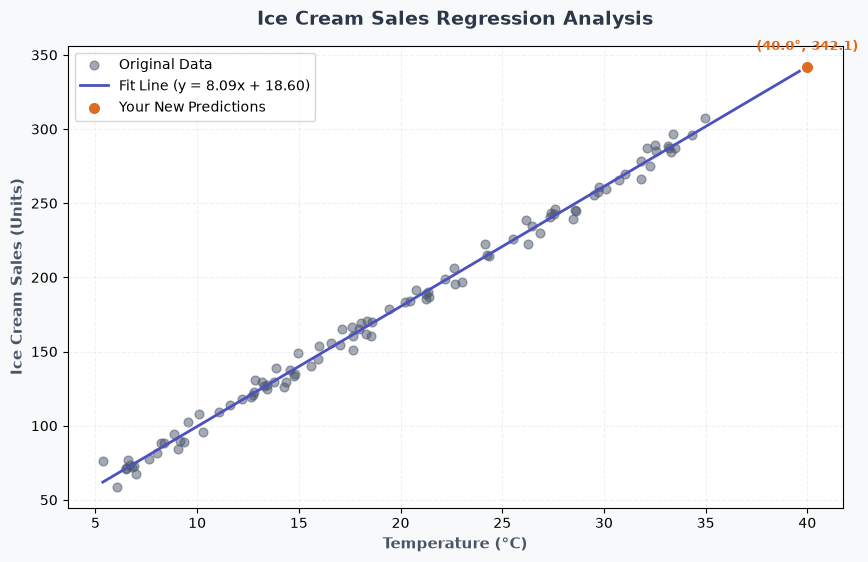

In [22]:
if new_X_inputs:
    # Set a clean, modern aesthetic style
    plt.figure(figsize=(10, 6), facecolor='#f8f9fa')

    # Original Data Plotting
    plt.scatter(X, Y, color='#4a5568', alpha=0.5, s=40, label='Original Data')
    
    # Continuous Trend Line starting from b to maximum value of y or predicted Y
    x_line = np.linspace(min(X.min(), min(new_X_inputs)), max(X.max(), max(new_X_inputs)), 100)
    y_line = (m * x_line) + b
    plt.plot(x_line, y_line, color='#4c51bf', linewidth=2, label=f'Fit Line (y = {m:.2f}x + {b:.2f})') #label is in f string to show how plotted values of X and Y like 1.5*X + 3
    
    # New Predicted Points 
    plt.scatter(new_X_inputs, new_Y_predictions, color='#dd6b20', marker='o', s=90, edgecolor='white', linewidth=1.5, zorder=5, label='Your New Predictions')
    
    # Text annotations for new points with co-ordinates of both X and Y 
    for xi, yi in zip(new_X_inputs, new_Y_predictions):
        plt.annotate(f"({xi}°, {yi:.1f})", (xi, yi), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9, fontweight='bold', color='#df681a')

    # Chart decorations
    plt.title('Ice Cream Sales Regression Analysis', fontsize=14, fontweight='bold', pad=15, color='#2d3748')
    plt.xlabel('Temperature (°C)', fontsize=11, fontweight='bold', color='#4a5568')
    plt.ylabel('Ice Cream Sales (Units)', fontsize=11, fontweight='bold', color='#4a5568')
    
    plt.grid(True, linestyle='--', alpha=0.3, color='#cbd5e0')
    plt.legend(loc='upper left')
    
    plt.show()
else:
    print("No new data was entered to plot. Insert First")


Now lets Calculate SSE and MSE

In [23]:
# 1. Calculate the predicted Y values for your original X data
Y_pred = (m * X) + b

# Calculate Sum of Squared Errors (Square FIRST, then Sum)
Sum_of_SquaredErrors = np.sum((Y - Y_pred) ** 2)     #It tells us that there are mistakes in the days of bussiness with forecasting.
print(f"SSE is: {Sum_of_SquaredErrors:.4f}")

# Calculate Mean Squared Error Which tells us on average days how many mistakes forecasting did Squared(It can be overestimaing and underestimating )
Mean_Squared_Errors = Sum_of_SquaredErrors / len(X)
print(f"MSE is: {Mean_Squared_Errors:.4f}")

# Calculate Root Mean Squared Error (tells you the average miss in sales units so you can keep enough stock on colder/warmer days). sqrt removes the effect of Squared value that heavily punished the model for metrics purpose.
Root_Mean_Squared_Error = np.sqrt(Mean_Squared_Errors)
print(f"RMSE is: {Root_Mean_Squared_Error:.4f}")

# Total Variance (How much sales naturally bounce around on their own)
Sum_of_Squares_Total = np.sum((Y - meanY) ** 2)

# R-Squared Formula
r_squared = 1 - (Sum_of_SquaredErrors / Sum_of_Squares_Total)

print(f"R-Squared (R²) Score is: {r_squared:.4f}")
print(f"This means temperature explains {r_squared*100:.1f}% of your ice cream sales fluctuations!")



SSE is: 2478.6238
MSE is: 24.7862
RMSE is: 4.9786
R-Squared (R²) Score is: 0.9950
This means temperature explains 99.5% of your ice cream sales fluctuations!


That was Just for Training on Normal Data and using Full Data to Train Forecasting 

Lets Go with Shuffling and divding data to get the 70/30 TRAIN and TEST scenario


In [24]:
# Shuffle your dataset randomly to prevent bias
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Calculate the split point (70% of 100 rows = 70)
split_index = int(len(df_shuffled) * 0.70)

# Partition into Train (70%) and Test (30%) DataFrames
train_df = df_shuffled.iloc[:split_index]
test_df = df_shuffled.iloc[split_index:]

# Extract your NumPy arrays for both sets
X_train = train_df['temperature_c'].values.astype(float)
Y_train = train_df['ice_cream_sales'].values.astype(float)

X_test = test_df['temperature_c'].values.astype(float)
Y_test = test_df['ice_cream_sales'].values.astype(float)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size:  {len(X_test)} samples")


Training set size: 70 samples
Testing set size:  30 samples


Lets ReCalculate our m and b values from Training data so we can get the REAL results of our Forecasting model 

In [25]:

# Compute means for Training Data using np.mean()
meanXt = np.mean(X_train)   
meanYt = np.mean(Y_train)

Xtm = X_train - meanXt
Ytm = Y_train - meanYt
XmYt = Xtm * Ytm

# Calculate the slope using sum of Products and X-Xbar raise to power 2
m = np.sum(XmYt) / np.sum(Xtm**2)

print(f"Beta 1 or Slope is : {m:.4f}")
b=meanYt-meanXt*m
print(f"Beta 0 or Bias is :{b:.4f}")


Beta 1 or Slope is : 8.1598
Beta 0 or Bias is :16.9400


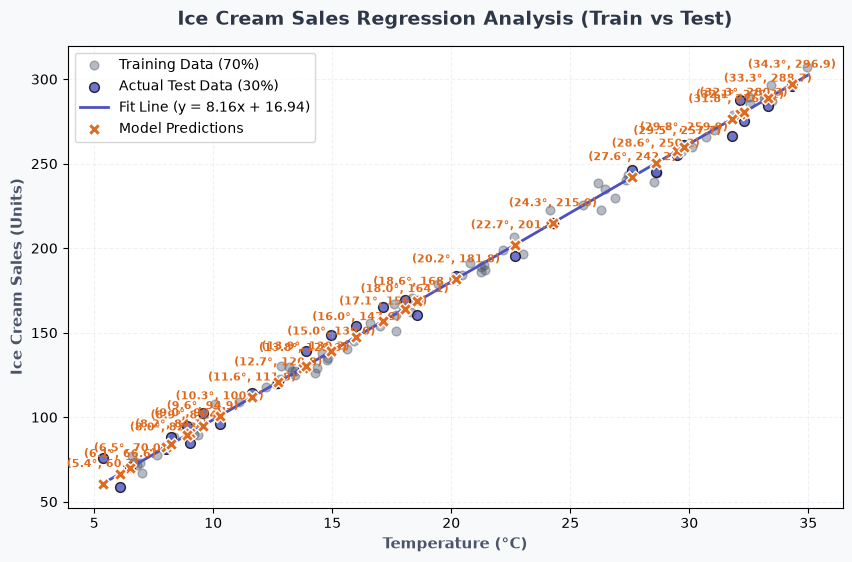

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), facecolor='#f8f9fa')

# Plot your TRAINING data points as background context
plt.scatter(X_train, Y_train, color='#4a5568', alpha=0.4, s=40, label='Training Data (70%)')

# FIXED: Plot your REAL UNSEEN TESTING data points so you can compare reality vs predictions
plt.scatter(X_test, Y_test, color='#4c51bf', alpha=0.8, s=50, edgecolors='black', label='Actual Test Data (30%)')

# Continuous Trend Line starting from your data minimums to maximums
x_line = np.linspace(min(X_train.min(), X_test.min()), max(X_train.max(), X_test.max()), 100)
y_line = (m * x_line) + b
plt.plot(x_line, y_line, color='#4c51bf', linewidth=2, label=f'Fit Line (y = {m:.2f}x + {b:.2f})')

# Predict test values for your scatter marker positions
y_pred = m * X_test + b

# New Predicted Points marked on your trendline
plt.scatter(X_test, y_pred, color='#dd6b20', marker='X', s=80, edgecolor='white', linewidth=1, zorder=5, label='Model Predictions')

# Text annotations for new points with dynamic vertical offsets to prevent line clutter
for xi, yi in zip(X_test, y_pred):
    line_y_at_x = (m * xi) + b
    y_offset = 12 if yi >= line_y_at_x else -20
    plt.annotate(f"({xi:.1f}°, {yi:.1f})", (xi, yi), textcoords="offset points", xytext=(0, y_offset), ha='center', fontsize=8, fontweight='bold', color='#df681a')

# Chart decorations
plt.title('Ice Cream Sales Regression Analysis (Train vs Test)', fontsize=14, fontweight='bold', pad=15, color='#2d3748')
plt.xlabel('Temperature (°C)', fontsize=11, fontweight='bold', color='#4a5568')
plt.ylabel('Ice Cream Sales (Units)', fontsize=11, fontweight='bold', color='#4a5568')

plt.grid(True, linestyle='--', alpha=0.3, color='#cbd5e0')
plt.legend(loc='upper left')

# FIXED: Save the figure BEFORE calling plt.show() clears the canvas buffer
plt.savefig("delete.png", bbox_inches='tight')
plt.show()


In [27]:
# 1. Calculate the predicted Y values for your original X data
Y_pred = (m * X_test) + b

# Calculate Sum of Squared Errors (Square FIRST, then Sum)
Sum_of_SquaredErrors = np.sum((Y_test - Y_pred) ** 2)     #It tells us that there are mistakes in the days of bussiness with forecasting.
print(f"SSE is: {Sum_of_SquaredErrors:.4f}")

# Calculate Mean Squared Error Which tells us on average days how many mistakes forecasting did Squared(It can be overestimaing and underestimating )
Mean_Squared_Errors = Sum_of_SquaredErrors / len(X_test)
print(f"MSE is: {Mean_Squared_Errors:.4f}")

# Calculate Root Mean Squared Error (tells you the average miss in sales units so you can keep enough stock on colder/warmer days). sqrt removes the effect of Squared value that heavily punished the model for metrics purpose.
Root_Mean_Squared_Error = np.sqrt(Mean_Squared_Errors)
print(f"RMSE is: {Root_Mean_Squared_Error:.4f}")

# Total Variance (How much sales naturally bounce around on their own)
meanYtest=np.mean(Y_test)
Sum_of_Squares_Total = np.sum((Y_test - meanYtest) ** 2)

# R-Squared Formula
r_squared = 1 - (Sum_of_SquaredErrors / Sum_of_Squares_Total)

print(f"R-Squared (R²) Score is: {r_squared:.4f}")
print(f"This means temperature explains {r_squared*100:.1f}% of your ice cream sales fluctuations!")



SSE is: 1148.7387
MSE is: 38.2913
RMSE is: 6.1880
R-Squared (R²) Score is: 0.9933
This means temperature explains 99.3% of your ice cream sales fluctuations!
